### “How do we know the model isn’t just finding random patterns?”

In [155]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.optimize import minimize
from pathlib import Path

# plotting style
plt.rcParams.update({
    "font.size": 12,
    "axes.linewidth": 1.5,
    'figure.figsize' : [10.0, 3.0],
    'figure.dpi' :300,
    'image.aspect': 7 
})


########################################################################
DATA_PATH = '../data/'
FIGURE_PATH = '../figures/'

RAW_FILE =  DATA_PATH+'raw/Main_Data.xls'
PARKS_FILE =  DATA_PATH+'raw/national_parks_lookup.csv'

VISITS_FILE =  DATA_PATH+'processed/monthly_visitation.csv'
INTERVENTION_FILE =  DATA_PATH+'processed/park_intervention_flags.csv'

DONOR_FILE = DATA_PATH+'processed/donor_pool.csv'
RESULTS_FILE = DATA_PATH+'processed/synthetic_results.csv'
WEIGHTS_FILE = DATA_PATH+'processed/synthetic_weights.csv'

### 1. Pre-treatment fit (Root-mean square error) 

In [156]:
results = pd.read_csv(RESULTS_FILE)
weights = pd.read_csv(WEIGHTS_FILE)
visits = pd.read_csv(VISITS_FILE)
donors = pd.read_csv(DONOR_FILE)

# create pre-period 
pre = results[results["year"] <=2019]

In [157]:
# calculate root-mean-square error 
pre_rmse = np.sqrt(np.mean((pre["actual_rmnp"]-pre["synthetic_rmnp"])**2))
pre_rmse

np.float64(2.5547797524382356)

In [158]:
# calculate relative error 
pre_rmse_percent = (pre_rmse/pre["actual_rmnp"].mean() * 100)
pre_rmse_percent 

np.float64(2.0391030635376968)

Synthetic RMNP recreated pre-treatment visitation within ~2%.

### 2. Post-treatment gap ratio 
Was the post-2021 difference larger than normal model error? 

In [159]:
post = results[results["year"] > 2021]

# average absolute gaps 
pre_gap = (abs(pre["actual_rmnp"] - pre["synthetic_rmnp"]).mean())

post_gap = (abs(post["actual_rmnp"] - post["synthetic_rmnp"]).mean())

gap_ratio = post_gap/pre_gap

gap_ratio


np.float64(9.644610950011252)

After the evaluation period began, RMNP’s divergence from synthetic RMNP was ~9.6 times larger than the typical modeling error observed before timed entry.

### 3. Placebo test

Would we find similar effects if we pretended other parks recieved timed entry?

For ever donor, we pretend they have timed entry, build synthetic model, measure the effect, and then compare the results with RMNP 

In [160]:
# Create the same matrix used

START_YEAR = 2010
END_YEAR = 2025

TREATMENT_YEAR = 2021

# Peak summer visits 
peak = (visits[visits["month"].isin([6,7,8,9])].groupby(["park_code", "park_name", "year"])["visits"].sum().reset_index(name="outcome"))
# 2010-2025 filter 
data = peak[peak["year"].between(START_YEAR, END_YEAR)].copy()
# RMNP + elgibile donors 
eligible_donors = (donors[donors["comparable_donor"] == 1]["park_code"].tolist())
model_data = data[(data["park_code"] == "ROMO") | (data["park_code"].isin(eligible_donors))]
# year x park matrix 
matrix = (model_data.pivot(index="year", columns = "park_code", values = "outcome"))
# indexed all parks to 2010 = 100 
matrix_indexed = (matrix/matrix.loc[2010]*100)


In [196]:
def run_synthetic_control(matrix, treated_unit, treatment_year=2021):

    # clean matrix
    matrix = (matrix.replace([np.inf, -np.inf], np.nan).dropna(axis=1).astype(float))
    
    if treated_unit not in matrix.columns:
        raise ValueError(f"{treated_unit} not found in matrix columns.")
    # Drop missing donor columns, but never before checking treated unit
    valid_cols = matrix.dropna(axis=1).columns

    if treated_unit not in valid_cols:
        raise ValueError(f"{treated_unit} has missing values and cannot be used as treated unit.")
    
    matrix = matrix[valid_cols]
    # treated unit 
    Y = matrix[treated_unit]
    # donor units 
    X = matrix.drop(columns=treated_unit)
    
    # pre-treatment period
    pre_years = matrix.index <= 2019

    Y_pre = Y.loc[pre_years]
    X_pre = X.loc[pre_years]

    assert np.isfinite(X_pre).all().all()
    assert np.isfinite(Y_pre).all()

    # loss function
    def loss(weights):
        synthetic = (X_pre.to_numpy(dtype=float) @ weights)

        if not np.isfinite(synthetic).all():
            return 1e10

        error = (Y_pre.to_numpy(dtype=float)-synthetic)

        if not np.isfinite(error).all():
            return 1e10

        return np.mean(error ** 2)

    n_controls = X_pre.shape[1]

    constraints = {"type": "eq","fun": lambda w: np.sum(w) - 1}
    bounds = [(0,1)] * n_controls

    initial = (np.ones(n_controls)/n_controls)
    result = minimize(loss,initial,method="SLSQP",bounds=bounds,constraints=constraints,options={"maxiter": 1000})

    if not result.success:raise RuntimeError(f"Optimization failed: {result.message}")

    weights = result.x

    # final synthetic
    synthetic = (X.to_numpy(dtype=float)@ weights)
    
    output = pd.DataFrame({"year": matrix.index, "actual": Y.values, "synthetic": synthetic})
    
    output["effect"] = (output["actual"]-output["synthetic"])
    
    weights_df = pd.DataFrame({"park_code": X.columns, "weight": weights})

    return output, weights_df

In [200]:
# run the placebo models 

placebo_results = []
failed_placebos = []

for park in matrix_indexed.columns:
    try:
        result, w = run_synthetic_control(matrix_indexed,treated_unit=park)

        result["park_code"] = park
        placebo_results.append(result)

    except Exception as e:
        failed_placebos.append({
            "park_code": park,
            "error": str(e)})

placebos = pd.concat(placebo_results, ignore_index=True)

failed_placebos

[{'park_code': 'NEPE',
  'error': 'Optimization failed: Positive directional derivative for linesearch'}]

In [201]:
placebos

,year,actual,synthetic,effect,park_code
0,2010,100.000000,100.000000,-6.906475e-12,BADL
1,2011,87.163689,87.146546,1.714267e-02,BADL
2,2012,83.899050,84.180608,-2.815581e-01,BADL
3,2013,90.209995,90.173834,3.616108e-02,BADL
4,2014,86.282162,86.470384,-1.882220e-01,BADL
...,...,...,...,...,...
651,2021,163.912007,139.072448,2.483956e+01,ZION
652,2022,146.981436,133.097495,1.388394e+01,ZION
653,2023,154.103364,140.250048,1.385332e+01,ZION
654,2024,158.692805,137.220940,2.147187e+01,ZION


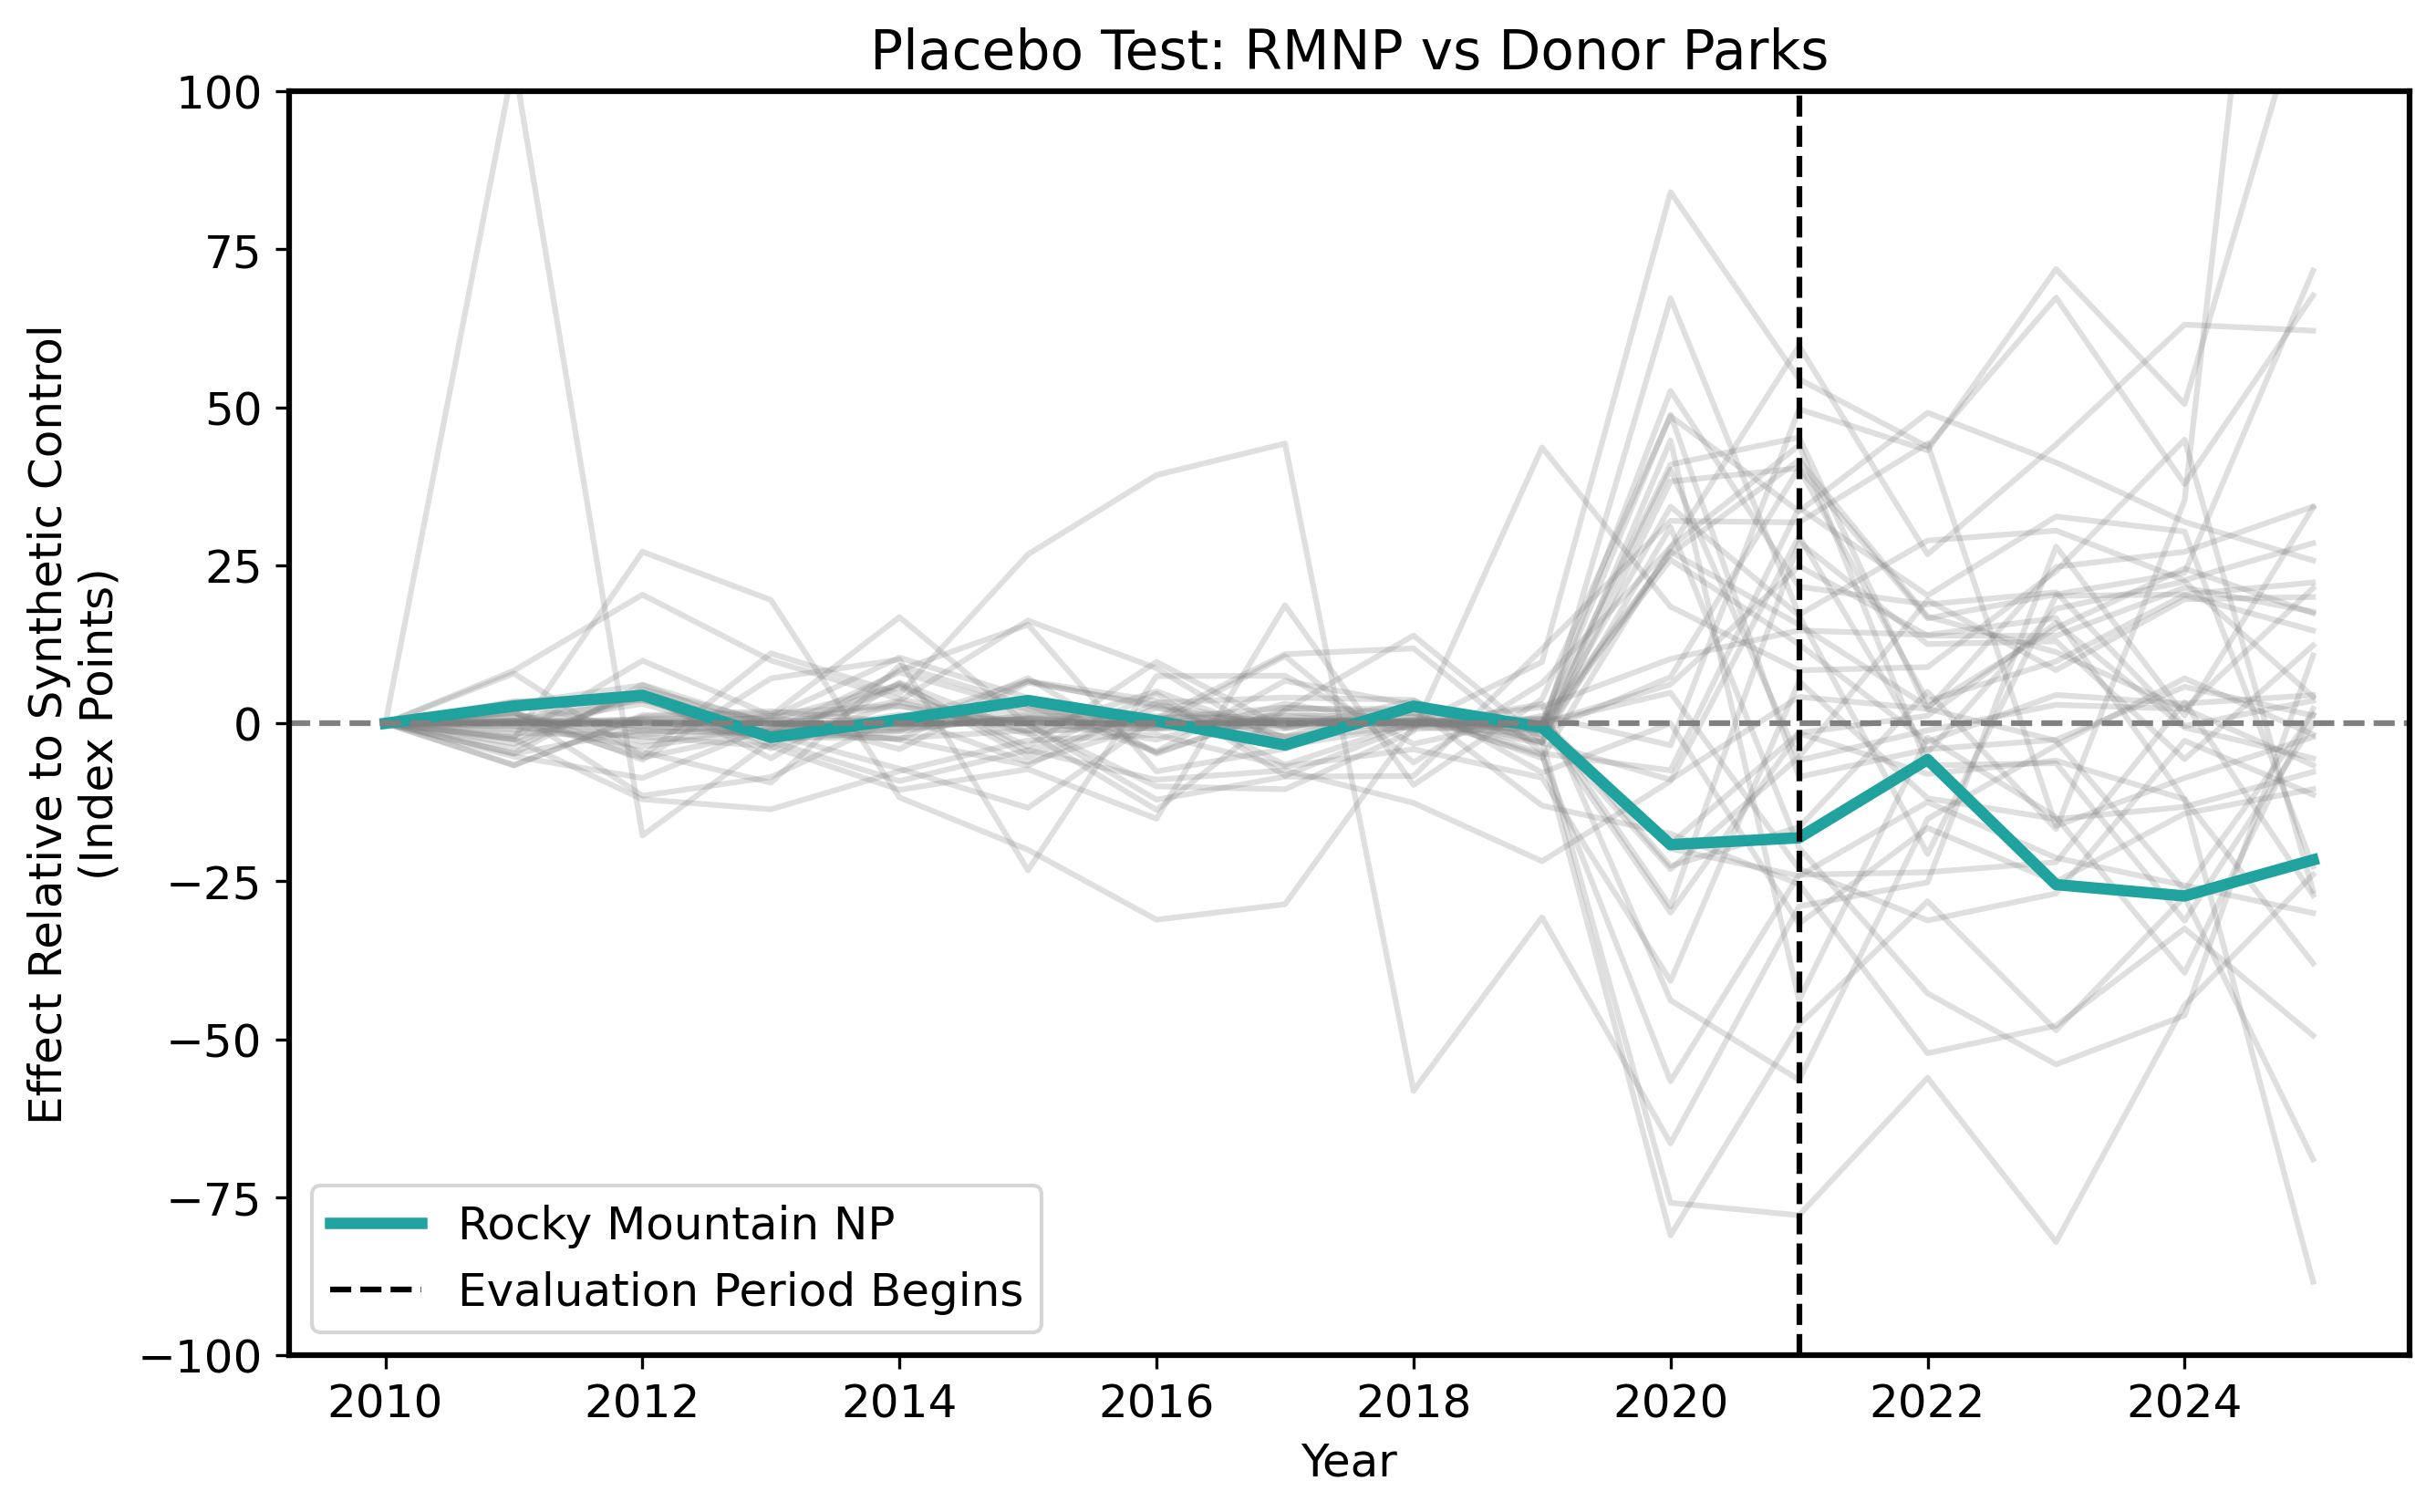

In [202]:
plt.figure(figsize=(10,6))

for park in placebos["park_code"].unique():
    temp = placebos[placebos["park_code"] == park]
    
    if park != "ROMO":
        plt.plot(temp["year"], temp["effect"], c="gray", alpha=0.25)

rmnp = placebos[placebos["park_code"] == "ROMO"]

plt.plot(rmnp["year"], rmnp["effect"], c="#20a39e", linewidth=3, label="Rocky Mountain NP")

plt.axvline(2021, linestyle="--", c="black", label="Evaluation Period Begins")

plt.axhline(0,linestyle="--",c="gray")

plt.title("Placebo Test: RMNP vs Donor Parks")
plt.ylim([-100,100])
plt.xlabel("Year")
plt.ylabel("Effect Relative to Synthetic Control\n(Index Points)")
plt.legend()
plt.show()

In [203]:
# Calculate pseudo p-value 
post_effects = (placebos[placebos["year"] >= 2021].groupby("park_code")["effect"].mean())

rmnp_effect = abs(post_effects.loc["ROMO"])

pseudo_p = (post_effects.abs() >= rmnp_effect).mean()

pseudo_p

np.float64(0.34146341463414637)

The pseudo p-value represents the share of placebo parks with an estimated post-treatment effect at least as large as RMNP's. So this here means that about 35.7% of placebo parks had a post-treatment gap as large as or larger than RMNP’s gap. This is not extremely unsual compared with other parks in the donor pool. 

In [204]:
placebo_filename = 'placebo_results.csv'

placebos.to_csv(DATA_PATH+'processed/'+placebo_filename)

To avoid comparing RMNP against poorly reconstructed placebo units, the placebo test was repeated after removing parks with pre-treatment RMSE more than twice RMNP’s. This ensures the comparison focuses only on parks where synthetic control produced a credible counterfactual.

### Lets calculate the placebo RMSE 

In [205]:
pre_fit = (placebos[placebos["year"] <= 2019].assign(squared_error=lambda x:(x["actual"] - x["synthetic"]) ** 2)
    .groupby("park_code")
    ["squared_error"]
    .mean()
    .pow(0.5))

pre_fit.sort_values()

park_code
SHEN     0.000224
GRSM     0.000419
GRTE     0.126439
GRCA     0.228345
BADL     0.401188
MACA     0.482111
MEVE     0.845178
WHSA     1.220426
YELL     1.467972
WICA     1.672841
ZION     1.799228
VOYA     2.428512
CUVA     2.429247
ROMO     2.554780
SAGU     2.584572
LAVO     2.717417
HOSP     2.944337
OLYM     2.976906
CANY     2.977902
CARE     3.226693
CAVE     3.442666
THRO     3.448660
REDW     3.737215
CRLA     3.968286
BISC     4.017967
KICA     4.446072
GRBA     4.569851
BIBE     4.782868
GRSA     6.624590
DEVA     7.067088
GUMO     7.352679
BRCA     7.489027
JOTR     7.499888
PEFO     7.746849
EVER     9.010182
CONG     9.240621
INDU     9.316487
BLCA    16.472769
JEFF    18.591045
HAVO    29.623299
PINN    34.875021
Name: squared_error, dtype: float64

In [206]:
# Find RMNP 
rmnp_rmse = pre_fit.loc["ROMO"]

rmnp_rmse

np.float64(2.554779728316131)

In [207]:
# Keep reasonable comparison 
good_placebos = pre_fit[pre_fit <= rmnp_rmse * 2].index

In [208]:
# Lets now re-calculate 
filtered_placebos = placebos[placebos["park_code"].isin(good_placebos)]

In [209]:
# Calculate average post-treatment effect for each park
filtered_post_effects = (filtered_placebos[filtered_placebos["year"] >= 2021].groupby("park_code")["effect"].mean())

# RMNP absolute effect
rmnp_effect = abs(filtered_post_effects.loc["ROMO"])

# Share of placebo parks with effects >= RMNP
filtered_pseudo_p = (filtered_post_effects.abs() >= rmnp_effect).mean()

# fraction of well-fit placebo parks with an effect as large as RMNP 
print (filtered_pseudo_p)

0.2857142857142857


In [210]:
print(f"Original pseudo p-value: {pseudo_p:.3f}")
print(f"Filtered pseudo p-value: {filtered_pseudo_p:.3f}")
print(f"Placebos retained: {len(good_placebos)}")

Original pseudo p-value: 0.341
Filtered pseudo p-value: 0.286
Placebos retained: 28


With the original p-value being 0.357, the evidence is moderate. 

After removing poor synthetic matches, 29% of well-matched placebo parks show changes comparable to RMNP. There is evidence of a reduction relative to synthetic RMNP, but the effect is not uniquely large among post-2020 national park visitation changes.


This motivates the question, was RMNP unusal in either direction? If time entry should reduce peak-season visitation, how many parks had decreases as large as RMNP? 

In [211]:
rmnp_effect = (filtered_post_effects.loc["ROMO"])

directional_pseudo_p = (filtered_post_effects <= rmnp_effect).mean()

directional_pseudo_p

np.float64(0.10714285714285714)

In [212]:
# was RMNP unusal at all? 
print(f"Two-sided pseudo p-value: {filtered_pseudo_p:.3f}")
# Was RMNP's decline unusally large? 
print(f"Directional pseudo p-value: {directional_pseudo_p:.3f}")

Two-sided pseudo p-value: 0.286
Directional pseudo p-value: 0.107


Placebo testing showed that RMNP's overall post-treatment deviation was not extreme compared with all possible visitation changes among donor parks (two-sided pseudo p = 0.286), reflecting substantial system-wide changes in park visitation after 2020.

However, when testing the directional hypothesis that timed entry reduced peak-season visitation, RMNP showed a relatively uncommon decline (directional pseudo p = 0.107), with only ~11% of comparable placebo parks experiencing reductions of similar magnitude.

### Sensitivity Analysis 

##### Test 1: Donor Pool Selection
The main synthetic control model restricted donors to comparable, road-accessible National Parks without major visitor reservation systems.

As a robustness check, the model was repeated using a broader donor pool to test whether results depended on donor selection criteria.

In [213]:
def summarize_effect(results):
    post = results[results["year"] >= 2021]
    return (post["effect"].mean())

def summarize_percent_effect(results):
    post = results[results["year"] >= 2021]
    return ((post["actual"] - post["synthetic"])/ post["synthetic"] * 100).mean()

In [214]:
donor_tests = {}

# main donor pool 
donor_tests["comparable"] = matrix_indexed

# broad donor pool 
broad_donors = (donors[donors["intervention_type"] == 'none']["park_code"].tolist())

broad_data = data[(data["park_code"] == "ROMO") | (data["park_code"].isin(broad_donors))]
broad_matrix = (broad_data.pivot(index="year", columns = "park_code", values = "outcome"))

broad_matrix = (broad_matrix / broad_matrix.loc[2010]*100)

donor_tests["broad"] = broad_matrix

In [215]:
sensitivity_results = []

for name, test_matrix in donor_tests.items():
    result, comp_weights = run_synthetic_control(test_matrix, "ROMO")

    effect = summarize_effect(results)

    sensitivity_results.append({ "test": name, "avg_effect": effect})

sensitivity_df = pd.DataFrame(sensitivity_results)
sensitivity_df

sensitivity_df["percent_effect"] = [
    summarize_percent_effect(comp_results),
    summarize_percent_effect(broad_results)]

sensitivity_df.round(2)

,test,avg_effect,percent_effect
0,comparable,-19.66,-13.41
1,broad,-19.66,-14.39


Expanding the donor pool from 42 comparable parks to 56 eligible parks produced a similar estimated treatment effect despite selecting a different set of donor weights. This suggests that the estimated post-treatment gap was not driven by a single donor selection assumption.

In [216]:
comp_results, comp_weights = run_synthetic_control(matrix_indexed, "ROMO")

comp_weights.sort_values("weight",ascending=False).head(10)

broad_results, broad_weights = run_synthetic_control(broad_matrix,"ROMO")

broad_weights.sort_values("weight", ascending=False).head(10)

,park_code,weight
0,BADL,0.018182
41,OLYM,0.018182
30,KATM,0.018182
31,KEFJ,0.018182
32,KICA,0.018182
33,KOVA,0.018182
34,LACL,0.018182
35,LAVO,0.018182
36,MACA,0.018182
37,MEVE,0.018182


In [217]:
def calc_pre_rmse(results):
    pre = results[results["year"] <= 2019]

    return np.sqrt(np.mean((pre["actual"]-pre["synthetic"])**2))

In [218]:
print("Comparable:",calc_pre_rmse(comp_results))

print("Broad:",calc_pre_rmse(broad_results))

## add that to the sensitivity table 
sensitivity_df["pre_rmse"] = [calc_pre_rmse(comp_results),calc_pre_rmse(broad_results)]


Comparable: 2.554779728316131
Broad: 18.372285500080068


The broader donor pool achieved a lower pre-treatment RMSE because the model had access to additional parks. However, both donor specifications produced similar post-treatment estimates, suggesting the estimated effect was not driven by the initial donor selection criteria.

The comparable donor pool was retained as the primary specification because it provides a more theoretically appropriate counterfactual for RMNP visitation.

### Sensitivity test #2 : Time Window Sensitivity


The primary synthetic control model was trained using 2010–2019 visitation trends. As a robustness check, the model was repeated using a shorter 2015–2019 pre-treatment window.

This tests whether the estimated timed-entry effect depends on the selected historical comparison period.

2010-2019 --> train synthetic control 

(2020 is COVID so we are removing it )

2021-2025 --> evaulate effect 


In [219]:
time_tests = [(2010, "2010-2019"), (2015, "2015-2019")]

In [220]:
time_results = [] 

for start_year, label in time_tests:
    temp = matrix[matrix.index >= start_year]

    temp_indexed = (temp/temp.loc[start_year]*100)
    result, w = run_synthetic_control(temp_indexed, "ROMO")

    avg_effect = (result[result["year"] >= 2021]["effect"].mean())

    pre_rmse = calc_pre_rmse(result)

    time_results.append({"training_window": label, 
                         "pre_rmse":pre_rmse,
                         "avg_effect":avg_effect}
                       )
    
time_sensitivity = pd.DataFrame(time_results)
time_sensitivity

,training_window,pre_rmse,avg_effect
0,2010-2019,2.554780,-19.659464
1,2015-2019,0.000097,-22.594327


The estimated treatment effect remained consistent across alternative training periods. The main 2010–2019 model estimated a reduction of approximately 19.7 index points, while the shorter 2015–2019 model estimated a reduction of approximately 22.6 index points.

The 2015–2019 specification achieved a near-perfect pre-treatment fit because the shorter time window provides fewer observations relative to the number of possible donor parks. Therefore, the 2010–2019 window was retained as the primary model because it balances model fit with a longer historical comparison period.

### Outcome Sensitivity

The main analysis defines crowding as peak-season visitation (June–September). However, timed entry may affect visitation patterns in different ways.

To test this, the synthetic control model was repeated using alternative outcomes:
- Annual recreation visits
- Peak-season share of annual visitation

This evaluates whether timed entry reduced overall demand or specifically changed seasonal crowding patterns.

In [221]:
def create_outcome_matrix(outcome_df,outcome_column):

    model_data = (outcome_df[(outcome_df["park_code"] == "ROMO") |( outcome_df["park_code"].isin(eligible_donors))].copy())

    matrix = (model_data.pivot(index="year", columns="park_code", values=outcome_column))
    # remove parks with incomplete history 
    matrix = matrix.dropna(axis=1)

    # valid baseline 
    baseline = matrix.loc[2010]
    valid_cols = baseline[baseline.notna() & (baseline != 0)].index

    matrix = matrix[valid_cols]
    
    matrix_indexed = (matrix/matrix.loc[2010] *100)

    # remove any remaining inf/nan
    matrix_indexed = (matrix_indexed.replace([np.inf, -np.inf], np.nan).dropna(axis=1))
    return matrix_indexed

In [228]:
# peak seasons 
peak_matrix = peak_matrix.loc[2010:2025]

# annual visits outcome 
annual = (visits.groupby(["park_code", "park_name", "year"])["visits"].sum().reset_index(name = "annual_visits"))

# create matrix 
annual_matrix = create_outcome_matrix(annual, "annual_visits")
annual_matrix = annual_matrix.loc[2010:2025]

# peak season share 
peak_total = (visits[visits["month"].isin([6,7,8,9])].groupby(["park_code", "park_name","year"])["visits"].sum().reset_index(name="peak_visits"))
annual_total = (visits.groupby(["park_code", "park_name", "year"])["visits"].sum().reset_index(name="annual_visits"))
peak_share = annual_total.merge(peak_total, on = ["park_code", "park_name", "year"])
peak_share["peak_share"] = (peak_share["peak_visits"]/peak_share["annual_visits"])

share_matrix = create_outcome_matrix(peak_share, "peak_share")
share_matrix = share_matrix.loc[2010:2025]


In [229]:
print(peak_matrix.shape)
print(annual_matrix.shape)
print(share_matrix.shape)

(16, 42)
(16, 41)
(16, 41)


In [230]:
peak_results, peak_weights = run_synthetic_control(peak_matrix,"ROMO")

annual_results, annual_weights = run_synthetic_control(annual_matrix,"ROMO")

share_results, share_weights = run_synthetic_control(share_matrix,"ROMO")

In [231]:
outcome_sensitivity = pd.DataFrame([{
        "outcome": "Peak-season visits",
        "pre_rmse": calc_pre_rmse(peak_results),
        "avg_effect": summarize_effect( peak_results),
        "percent_effect": summarize_percent_effect( peak_results)},
        {"outcome": "Annual visits",
         "pre_rmse": calc_pre_rmse(annual_results),
         "avg_effect": summarize_effect(annual_results),
         "percent_effect": summarize_percent_effect(annual_results)},
        {"outcome": "Peak-season share", 
         "pre_rmse": calc_pre_rmse(share_results),
         "avg_effect": summarize_effect(share_results),
         "percent_effect": summarize_percent_effect(share_results)}])

outcome_sensitivity.round(2)

,outcome,pre_rmse,avg_effect,percent_effect
0,Peak-season visits,2.55,-19.66,-13.41
1,Annual visits,2.89,-28.69,-16.57
2,Peak-season share,0.00,4.36,5.28


After timed entry, RMNP had approximately 13% fewer June–September visits than expected based on comparable parks.

Overall annual visitation was also lower than expected (~16%).

The proportion of visits occurring during peak season actually increased relative to the synthetic counterfactual. Therefore, timed entry probably did not flatten seasonability. 

### Policy finding: 

So does timed entry reduce crowding? Base on this analysis, timed entry was associated with lower visitation at RMNP, including a 13% reduction in peak-season visits relative to the synthetic counterfactual. However, annual visitation declined by a similar magnitude, and peak-season concentratation did not decrease. This suggest timed entry reduced vistor volume rather than redistributing demand away from the croweded months. 